**An End-to-End Sentiment Analysis System Using Natural Language Processing (NLP) And Machine Learning (ML)**

In [1]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB  # Changed from GaussianNB which is less suited to text classification.
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import tkinter as tk
from tkinter import ttk
from PIL import Image, ImageTk
import os
import pickle

# Download the missing text processing datasets first!
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

**INITIAL EVALUATION**

In [2]:
# We will use the Flipkart dataset obtained from Kaggle for this project
df = pd.read_csv('FlipKartSentimentDataset.csv')
print(df.columns.tolist())

['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']


In [3]:
# We run the following code in the next few cells to get a good picture of the organization and content of the dataset. 
# We start with attributes.
df.shape

(205052, 6)

In [4]:
df.dtypes

product_name     object
product_price    object
Rate             object
Review           object
Summary          object
Sentiment        object
dtype: object

In [5]:
# Next we use methods.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [6]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [7]:
df.describe()

,product_name,product_price,Rate,Review,Summary,Sentiment
count,205052,205052,205052,180388,205041,205052
unique,958,525,8,1324,92923,3
top,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,wonderful,good,positive
freq,6005,9150,118765,9016,17430,166581


**PREPROCESSING TECHNIQUES**

> Looking at the preliminary data above, we decided to combine the "Review" and "Summary" columns into a single text feature string before passing it into 
our preprocessing pipeline. The purpose for doing this comes down to three main reasons:
1. Maximizing context and feature richness as more relevant context leads to better predictions. This ensures that our CountVectorizer
captures vocabulary and n-grams from both fields, giving our Naive Bayes model a much richer pool of features to learn from.
2. Streamlining the NLP preprocessing pipeline. Instead of having to run the heavy preprocessing function for each column, we only have to apply
the cleaning function once. This makes our preprocessing step faster and keeps our code much cleaner.
3. Adapting to a Single-Input Model Architecture. Instead of vectorizing each column separately, combining the relevant columns
at the dataframe level completely bypasses the extra matrix manipulation, allowing us to feed a single text variable 
(preprocessed_review) straight into (cv.fit_transform()). 

In [8]:
# 1. Define these ONCE outside the function so they stay in memory
lmtzr = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocessed_review(text):
    text = str(text)
    text = re.sub('<.*?>', '', text)    # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = text.lower()
    text = text.split()
    
# 2. Use the pre-loaded variables here (This makes it blazing fast)
    text = [lmtzr.lemmatize(word, 'v') for word in text if word not in stop_words]
    return " ".join(text)

> We have a dataset with over 200,000 rows.  In order to expedite preprocessing on our computer, we are only going to train the model on the first 
> 25,000 rows.  25,000 rows of data is still more than adequate for our sentiment analysis.

In [9]:
# We take a portion or subset of our entire dataset.
if 'Review' in df.columns and 'Summary' in df.columns:
    # 1. Slice the dataframe to take only the first 25,000 rows
    df_subset = df.head(25000).copy()
    
    # 2. Combine the columns efficiently using the subset
    combined_series = df_subset['Review'].fillna('').astype(str) + " " + df_subset['Summary'].fillna('').astype(str)
    print("Preprocessing text for the first 25,000 rows... Please wait...")
    
    # 3. Run the preprocessing function
    preprocessed_reviews = combined_series.apply(preprocessed_review).tolist()
    print(f"Successfully preprocessed {len(preprocessed_reviews)} combined reviews!")
else:
    print(f"Error: Missing columns. Available columns are: {list(df.columns)}")

Preprocessing text for the first 25,000 rows... Please wait...
Successfully preprocessed 25000 combined reviews!


**MODEL TRAINING CODE: NAIVE BAYES CLASSIFIER**

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB  # Changed from GaussianNB to 
# improve data structure compatibility and computational efficiency
import pickle

# Vectorize the text data
cv = CountVectorizer(max_features=5000, ngram_range=(1, 3))
X = cv.fit_transform(preprocessed_reviews)

# FIX: Map your actual string sentiments ('positive', 'neutral', 'negative') to numbers
sentiment_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
y = df_subset['Sentiment'].map(sentiment_mapping).fillna(0).tolist()

# Train the classifier on real data
classifier = MultinomialNB()
classifier.fit(X, y)

# Save the real model assets
with open('sentiment_model.pkl', 'wb') as model_file:
    pickle.dump(classifier, model_file)
with open('vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(cv, vec_file)

print("Model trained on real Flipkart data and saved successfully!")

Model trained on real Flipkart data and saved successfully!


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer

# 1. Split the preprocessed reviews and the 'y' labels we created 
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    preprocessed_reviews, 
    y, 
    test_size=0.2, 
    random_state=42
)

# 2. Use a temporary vectorizer to fit on the training split only
cv_eval = CountVectorizer(max_features=5000, ngram_range=(1, 3))
X_train_cv = cv_eval.fit_transform(X_train_nb)
X_test_cv = cv_eval.transform(X_test_nb)

# 3. Train a temporary evaluation model
eval_classifier = MultinomialNB()
eval_classifier.fit(X_train_cv, y_train_nb)

# 4. Generate and print the report
nb_predictions = eval_classifier.predict(X_test_cv)
print("Naive Bayes Classification Report:")
print(classification_report(y_test_nb, nb_predictions, target_names=['Negative', 'Neutral', 'Positive']))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.85      0.82       706
     Neutral       0.48      0.36      0.41       230
    Positive       0.96      0.96      0.96      4064

    accuracy                           0.92      5000
   macro avg       0.74      0.72      0.73      5000
weighted avg       0.91      0.92      0.91      5000



**NAIVE BAYES CONFUSION MATRIX**

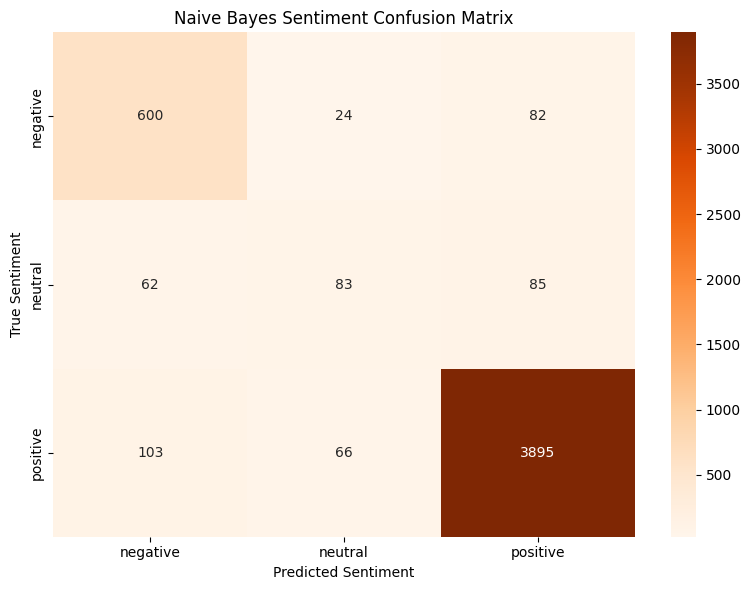

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix using your existing variables
cm_nb = confusion_matrix(y_test_nb, nb_predictions)

# 2. Define target names matching previous cell
target_names = ['negative', 'neutral', 'positive']

# 3. Plot the Naive Bayes confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, 
            yticklabels=target_names)

plt.title('Naive Bayes Sentiment Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.tight_layout()
plt.show()

**NAIVE BAYES MODEL TRAINED ON TF-IDF (TERM FREQUENCY - INVERSE DOCUMENT FREQUENCY)**

In [13]:
# 1. Initialize the TF-IDF Vectorizer (matching your max_features from CountVectorizer)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 3))

# 2. Transform your preprocessed text into TF-IDF features
X_tfidf = tfidf.fit_transform(preprocessed_reviews)

# 3. Create a separate train/test split for the TF-IDF features
# (Using the same random_state ensures the exact same rows are in both test sets)
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tfidf, df_subset['Sentiment'], test_size=0.2, random_state=42
)

# 4. Train a second Multinomial Naive Bayes model on the TF-IDF data
nb_tfidf_model = MultinomialNB()
nb_tfidf_model.fit(X_train_tf, y_train_tf)

# 5. Evaluate the TF-IDF model
tfidf_predictions = nb_tfidf_model.predict(X_test_tf)
print("---Naive Bayes with TF-IDF Classification Report ---")
print(classification_report(y_test_tf, tfidf_predictions))

---Naive Bayes with TF-IDF Classification Report ---
              precision    recall  f1-score   support

    negative       0.79      0.82      0.81       706
     neutral       0.82      0.18      0.30       230
    positive       0.94      0.98      0.96      4064

    accuracy                           0.92      5000
   macro avg       0.85      0.66      0.69      5000
weighted avg       0.91      0.92      0.91      5000



> To assess further accuracy, we introduce the Logistic Regression model and compare it against the 
two Naive Bayes model vectorizers.

**MODEL TRAINING CODE: LOGISTIC REGRESSION**

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pickle

# 1. Load Data
df = pd.read_csv("FlipKartSentimentDataset.csv")

# Fill any missing values in the text columns so the vectorizer doesn't crash
df['Review'] = df['Review'].fillna('')
df['Summary'] = df['Summary'].fillna('')

# Combine Review and Summary into a single text feature string
df['combined_text'] = df['Review'] + " " + df['Summary']

# ====================================================================
# CRITICAL FIX: Explicitly map target text strings to standard numbers
# This guarantees 'positive' is 1 and 'negative' is -1 for the math engine.
# ====================================================================
sentiment_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
df['mapped_sentiment'] = df['Sentiment'].str.strip().str.lower().map(sentiment_mapping)

# Drop rows if any sentiment labels didn't match our clean mapping dictionary
df = df.dropna(subset=['mapped_sentiment'])
df['mapped_sentiment'] = df['mapped_sentiment'].astype(int)

# 2. Split & Vectorize using our clean, mapped numerical target
X_train, X_test, y_train, y_test = train_test_split(
    df['combined_text'],
    df['mapped_sentiment'], # <-- FIXED: Passing the clean numeric array here
    test_size=0.2,
    random_state=44
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 3. Train Classifier
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Define y-pred
y_pred = model.predict(X_test_vec)

# 4. Evaluate to confirm high accuracy
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# 5. Export clean files over your old picklestore files
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("\nModel trained properly and exported successfully!")

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

    Negative       0.88      0.90      0.89      5743
     Neutral       0.72      0.40      0.51      2013
    Positive       0.96      0.98      0.97     33255

    accuracy                           0.94     41011
   macro avg       0.85      0.76      0.79     41011
weighted avg       0.94      0.94      0.94     41011


Model trained properly and exported successfully!


**LOGISTIC REGRESSION CONFUSION MATRIX**

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# ==============================================================================
# 1. LOAD THE GENUINE LOGISTIC REGRESSION ARTIFACTS
# ==============================================================================
with open('logistic_regression_model.pkl', 'rb') as model_file:
    lr_model = pickle.load(model_file)
    
with open('vectorizer.pkl', 'rb') as vec_file:
    tfidf = pickle.load(vec_file)

# ==============================================================================
# 2. LOAD AND FEATURE ENGINEER THE DATASET
# ==============================================================================
df = pd.read_csv('FlipKartSentimentDataset.csv', encoding='ISO-8859-1')

# Replicate the missing feature engineering steps
df['Review'] = df['Review'].fillna('')
df['Summary'] = df['Summary'].fillna('')
df['combined_text'] = df['Review'].astype(str) + " " + df['Summary'].astype(str)

# Map labels to structural numerical targets (-1, 0, 1) safely
sentiment_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
df['mapped_sentiment'] = df['Sentiment'].astype(str).str.lower().str.strip().map(sentiment_mapping)

# Ensure no unmapped rows corrupt the evaluation split array
df = df.dropna(subset=['mapped_sentiment'])

# ==============================================================================
# 3. REPLICATE THE TRAINING EVALUATION SPLIT
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    df['combined_text'], 
    df['mapped_sentiment'], 
    test_size=0.2, 
    random_state=44
)

# ==============================================================================
# 4. TF-IDF MATRIX TRANSFORMATION & PREDICTION
# ==============================================================================
X_test_tfidf = tfidf.transform(X_test)
y_pred_lr = lr_model.predict(X_test_tfidf)

# ==============================================================================
# 5. GENERATE AND PLOT THE GENUINE MATRIX HEATMAP
# ==============================================================================
cm_lr = confusion_matrix(y_test, y_pred_lr)
target_names = ['Negative', 'Neutral', 'Positive']



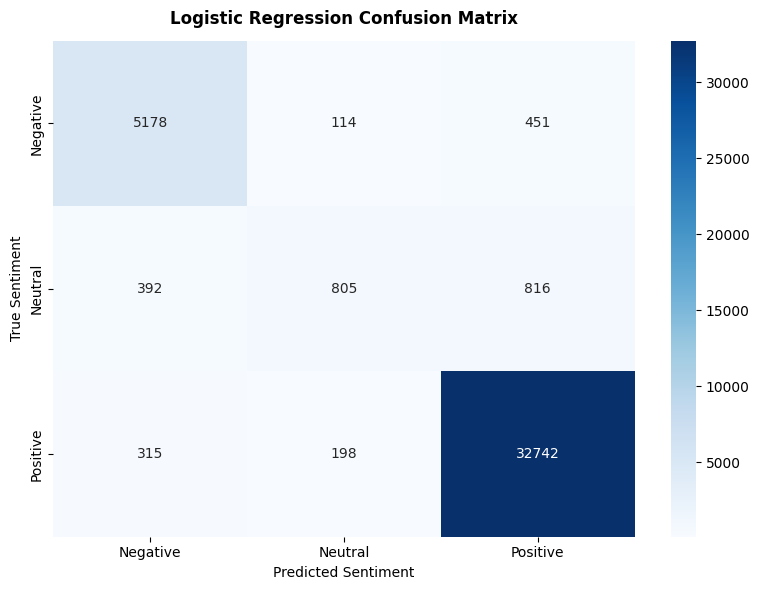

In [16]:
# Create the Logistic Regression Confusion Matrix and render a seaborn heatmap plot
plt.figure(figsize=(8, 6))

# Explicitly define clean labels without any numerical values (-1, 0, 1)
clean_labels = ['Negative', 'Neutral', 'Positive']

sns.heatmap(
    cm_lr, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=clean_labels,  # Cleans the horizontal axis
    yticklabels=clean_labels   # Cleans the vertical axis
)

plt.title('Logistic Regression Confusion Matrix', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Predicted Sentiment', fontsize=10)
plt.ylabel('True Sentiment', fontsize=10)
plt.tight_layout()
plt.show()

**F1 SCORE COMPARISON: NAIVE BAYES VS. LOGISTIC REGRESSION**

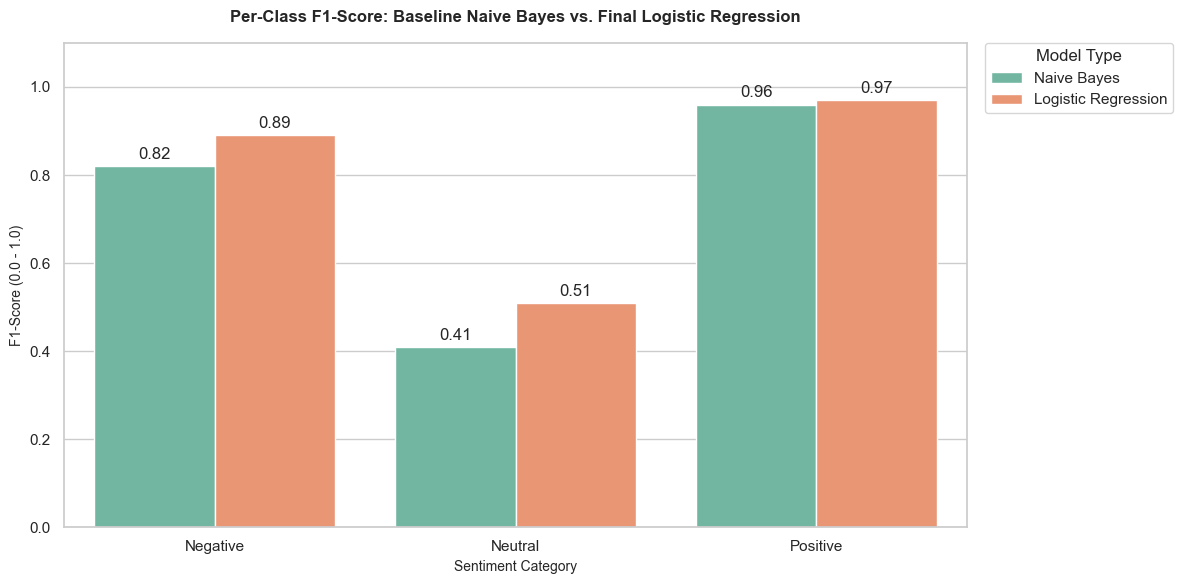

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Directly mapping the exact F1-Scores from our project's classification reports
plot_data = {
    'Model': ['Naive Bayes', 'Naive Bayes', 'Naive Bayes', 
              'Logistic Regression', 'Logistic Regression', 'Logistic Regression'],
    'Sentiment Class': ['Negative', 'Neutral', 'Positive', 
                       'Negative', 'Neutral', 'Positive'],
    'F1-Score': [0.82, 0.41, 0.96,  # Model 1 & 2 performance
                 0.89, 0.51, 0.97]   # Model 3 performance
}

# Convert to DataFrame
df_vis = pd.DataFrame(plot_data)

# Create the plot
plt.figure(figsize=(12, 6))  # Widened slightly to give the legend room on the right
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Sentiment Class', y='F1-Score', hue='Model', data=df_vis, palette='Set2')

# Add values on top of the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Per-Class F1-Score: Baseline Naive Bayes vs. Final Logistic Regression', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category', fontsize=10)
plt.ylabel('F1-Score (0.0 - 1.0)', fontsize=10)
plt.ylim(0, 1.1) 

# REPOSITIONED LEGEND: Moves it outside the main box to the upper right side
plt.legend(title='Model Type', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()

# Display the chart
plt.show()

**TKINTER GRAPHICAL USER INTERFACE ASSET GENERATION CODE**

In [18]:
import tkinter as tk
from tkinter import ttk
from PIL import Image, ImageTk
import pandas as pd
import os
import pickle

# Load the model and vectorizer
with open('sentiment_model.pkl', 'rb') as model_file:
    model = pickle.load(model_file)

with open('vectorizer.pkl', 'rb') as vec_file:
    vectorizer = pickle.load(vec_file)

# Load the dataset
reviews = pd.read_csv('FlipKartSentimentDataset.csv', encoding='ISO-8859-1')

In [19]:
# Emoji generator
from PIL import Image, ImageDraw, ImageFont

# Define the actual emoji characters and background colors
emojis = {
    'happy_emoji.png': ('😊', 'green'),
    'neutral_emoji.png': ('😐', 'orange'), 
    'angry_emoji.png': ('😠', 'red')
}

for filename, (emoji_char, bg_color) in emojis.items():
    # Create a clean 100x100 canvas
    img = Image.new('RGB', (100, 100), color=bg_color)
    canvas = ImageDraw.Draw(img)
    
    try:
        # On Windows, 'Segoe UI Emoji' natively supports full color emojis!
        font = ImageFont.truetype("seguiemj.ttf", 55)
    except IOError:
        try:
            # On macOS, Apple Color Emoji is used
            font = ImageFont.truetype("/System/Library/Fonts/Apple Color Emoji.ttc", 55)
        except IOError:
            # Fallback if specific emoji fonts aren't found
            font = ImageFont.load_default(size=40)

    # Draw the emoji cleanly in the absolute center
    canvas.text((50, 50), emoji_char, embedded_color=True, font=font, anchor="mm")
    
    # Save it to your folder
    img.save(filename)

print("Real color emoji assets generated successfully!")

Real color emoji assets generated successfully!


**TKINTER GRAPHICAL USER INTERFACE**

In [20]:
import tkinter as tk
import pickle
from tkinter import ttk
from PIL import Image, ImageTk

# We decided to create a user interface showing both models side-by-side so we can easily compare predictions.
# 1. Map dataset variable so Tkinter can find it
reviews = df

# 2. Load BOTH newly synchronized models safely
with open('sentiment_model.pkl', 'rb') as f:          # Your Naive Bayes model
    nb_model = pickle.load(f)
    
with open('logistic_regression_model.pkl', 'rb') as f: # Your newly trained Logistic Regression model
    lr_model = pickle.load(f)

with open('vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Clear any old hidden Tkinter instances safely
try:
    root.destroy()
except:
    pass

# ==========================================
# MAIN WINDOW SETUP
# ==========================================
root = tk.Tk()
root.title("Flipkart Sentiment Model Comparison Dashboard")
root.geometry("950x550")  

# Load emoji assets
happy_emoji = ImageTk.PhotoImage(Image.open('happy_emoji.png'))
neutral_emoji = ImageTk.PhotoImage(Image.open('neutral_emoji.png'))
angry_emoji = ImageTk.PhotoImage(Image.open('angry_emoji.png'))

# Shared clean numerical mapping dictionary
emoji_map = {1: happy_emoji, 0: neutral_emoji, -1: angry_emoji}

# ==========================================
# LEFT COLUMN: NAIVE BAYES
# ==========================================
nb_frame = tk.LabelFrame(root, text=" Naive Bayes Classifier ", font=("Helvetica", 12, "bold"), padx=15, pady=15)
nb_frame.grid(row=0, column=0, padx=20, pady=20, sticky="nsew")

nb_emoji_label = tk.Label(nb_frame)
nb_emoji_label.pack(pady=10)

nb_review_label = tk.Label(nb_frame, wraplength=400, justify="center", font=("Helvetica", 10))
nb_review_label.pack(pady=10, fill="both", expand=True)

# ==========================================
# RIGHT COLUMN: LOGISTIC REGRESSION
# ==========================================
lr_frame = tk.LabelFrame(root, text=" Logistic Regression Classifier ", font=("Helvetica", 12, "bold"), padx=15, pady=15)
lr_frame.grid(row=0, column=1, padx=20, pady=20, sticky="nsew")

lr_emoji_label = tk.Label(lr_frame)
lr_emoji_label.pack(pady=10)

lr_review_label = tk.Label(lr_frame, wraplength=400, justify="center", font=("Helvetica", 10))
lr_review_label.pack(pady=10, fill="both", expand=True)

# ==========================================
# UNIFIED UPDATE LOGIC (COMPLETELY CLEAN)
# ==========================================
current_index = [0]

def update_dashboards(index):
    review_heading = reviews["Review"].iloc[index] 
    summary_text = reviews["Summary"].iloc[index]
    display_text = f"Review: {review_heading}\n\nSummary: {summary_text}"
    
    # Mirror the exact raw string join used during model training
    combined_input = str(review_heading) + " " + str(summary_text)
    X_review = vectorizer.transform([combined_input]).toarray()
    
    # 1. Predict and update Naive Bayes Column
    nb_pred = nb_model.predict(X_review)[0]
    nb_emoji = emoji_map.get(int(nb_pred), neutral_emoji)
    nb_emoji_label.config(image=nb_emoji)
    nb_review_label.config(text=display_text)
    
    # 2. Predict and update Logistic Regression Column
    # Both models now return matching clean integers natively!
    lr_pred = lr_model.predict(X_review)[0]
    lr_emoji = emoji_map.get(int(lr_pred), neutral_emoji)
    lr_emoji_label.config(image=lr_emoji)
    lr_review_label.config(text=display_text)

def next_review():
    current_index[0] = (current_index[0] + 1) % len(reviews)
    update_dashboards(current_index[0])

def prev_review():
    current_index[0] = (current_index[0] - 1) % len(reviews)
    update_dashboards(current_index[0])

# ==========================================
# CENTRALIZED NAVIGATION CONTROLS
# ==========================================
btn_frame = tk.Frame(root)
btn_frame.grid(row=1, column=0, columnspan=2, pady=20)

prev_button = ttk.Button(btn_frame, text="◀ Previous Review", command=prev_review)
prev_button.pack(side="left", padx=20)

next_button = ttk.Button(btn_frame, text="Next Review ▶", command=next_review)
next_button.pack(side="left", padx=20)

root.grid_rowconfigure(0, weight=1)
root.grid_columnconfigure(0, weight=1)
root.grid_columnconfigure(1, weight=1)

# Render initial view
update_dashboards(current_index[0])
root.mainloop()